In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import offsetbox
import os.path
from sklearn.pipeline import Pipeline,make_pipeline, make_union
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.cluster import DBSCAN
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,make_scorer,precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
import catboost as cat
from catboost import CatBoostClassifier, Pool
import shap

%matplotlib inline

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin

In [43]:
#lectura del file de atributos
df = pd.read_csv('../Datos/ip_a_procesar.csv')



### wrapper class para poder procesar cualquier estimador desde crossValidation

In [44]:
class ClfSwitcher(BaseEstimator):

    def __init__(
        self, 
        estimator = SGDClassifier(),
    ):


        self.estimator = estimator


    def fit(self, X, y=None, **kwargs):
        self.estimator.fit(X, y)
        return self


    def predict(self, X, y=None):
        return self.estimator.predict(X)


    def predict_proba(self, X):
        return self.estimator.predict_proba(X)


    def score(self, X, y):
        return self.estimator.score(X, y)

In [45]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def transform(self, X, *_):
        if isinstance(X, pd.DataFrame):
            return pd.DataFrame(X[self.columns])
        else:
            raise TypeError("Este Transformador COLUMN SELECTOR solamente funciona en DF de Pandas")
    
    def fit(self, X, *_):
        return self
    

In [46]:
class GetDummiesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def transform(self, X, *_):
        if isinstance(X, np.ndarray):  #### modificacion para poder usar la funcion luego de un fillna
            X = pd.DataFrame(X,columns=self.columns)
            
        if isinstance(X, pd.DataFrame):
            return pd.get_dummies(X[self.columns], columns = self.columns, drop_first = True)
        else:
            print("Me Mandaste ", X)
            print(type(X))
            raise TypeError("Este Transformador DUMMIES solo funciona en DF de Pandas")
    
    def fit(self, X, *_):
        return self
    



#### Sufijo se usa cuando quiero evaluar un tipo de producto especifico o un modelo especifico, se anexa el sufijo a los archivos de salida

In [47]:
#df = df[df.plan_id == 5]
#sufijo = '_plan_5'
sufijo = '_CatBoost'
#sufijo =''     

#### Variables que uso para controlar los archivos de logs de las coorridas.... el sufijo depende del modelo y del tipo de poliza

#### Separo los datos

In [48]:
X = df.drop(columns='target')
Y = pd.Series(df.target)


In [49]:
#Separar los conjuntos

X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, random_state=42)

### Construccion de los pipes de procesamiento

#### Procesamos la plataforma completando los valores faltantes con el mayoritario que es Android

In [50]:
plataform_pipe = make_pipeline(ColumnSelector(['platform']),
                          SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Android'),
                          GetDummiesTransformer(['platform']))

#### Seleccionamos el tipo de plan, el tipo de vehiculo , como participa en el incidente y el sexo para compltar sus valores y transformar en dummies

In [51]:
plan_pipe = make_pipeline(ColumnSelector(       ['plan_id','tipo_de_vehiculo','participant_code','Sexo']),
                          SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0),
                          GetDummiesTransformer(['plan_id','tipo_de_vehiculo','participant_code','Sexo']))

#### con el resto de las columnas , solo las seleccionamos para poder integrarlas al pipe de procesamiento

In [52]:
other_pipe = make_pipeline(ColumnSelector(['is_0km', 'stated_amount','zip_code','riesgo_bcra',
                                           'cantidad_aseguradoras_previas', 'vehicle_score',
                                           'cantidad_siniestros','Edad','antiguedad_años',
                                           'ventana_31_dias','user_created']))                          

#### Unimos cada uno de los pipes y construimos el pipeline final

In [53]:
p = union = make_union(plan_pipe,
                       plataform_pipe,                   
                       other_pipe)

In [54]:
pasos = [('pre',p),
         ('fill_default',SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0)),
         ('scaler', StandardScaler()),
     #    ('pca', PCA()), 
         ('clf', ClfSwitcher())]
        

<font color='red'>Usabamos PCA pero en el analisis vimos que no hay una reduccion de dimensionalidad que valga la pena, asi que lo removimos</font> 


In [55]:
PCA_components = [12,18]

In [56]:
pipe =Pipeline(pasos)

# Armamos los parametros de tofos los modelos que usamos

In [58]:
param_grid = [
    {
    'clf__estimator': [LogisticRegression()],    
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],
  #  'pca':[PCA(PCA_components),None],
       
    'clf__estimator__C': np.logspace(-4, 8, 8),
    'clf__estimator__class_weight' :['balanced',{0:1,1:4},{0:1,1:6},{0:1,1:8}],
    'clf__estimator__multi_class':['auto','ovr','multinomial'],
    'clf__estimator__solver': ['lbfgs','liblinear', 'saga'],
    'clf__estimator__penalty': ('l2', 'elasticnet', 'l1'),
    'clf__estimator__l1_ratio':np.arange(0,1,0.1)
    },
    {
    'clf__estimator': [GaussianNB()],
    'clf__estimator__var_smoothing':np.arange(1e-11,1e-7,1e-8),
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],  
  #  'pca':[PCA(PCA_components),None],
    },   
     {
    'clf__estimator': [KNeighborsClassifier()],
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],  
   # 'pca':[PCA(PCA_components),None], 
    'clf__estimator__n_neighbors':[1,30],
    'clf__estimator__weights':['uniform','distance'],
    'clf__estimator__p':[2,3,4,5]
    },
    {
    'clf__estimator': [SGDClassifier()], # SVM if hinge loss / logreg if log loss
    'clf__estimator__penalty': ('l2', 'l1'),
    'clf__estimator__tol': [1e-3],
    'clf__estimator__alpha': [1e-3, 1e-2, 1e-1, 1e0, 1e1], # learning rate
    'clf__estimator__loss': ['hinge', 'squared_hinge'],
    'clf__estimator__class_weight':['uniform','distance',{0:1,1:4},{0:1,1:6},{0:1,1:8}],
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],  
  #  'pca':[PCA(PCA_components),None], 
    },
  
]
linearsvc = [
    {
    'clf__estimator': [LinearSVC()],    
    'scaler':[RobustScaler()],   
 #   'pca__n_components': PCA_components,    
    'clf__estimator__C': np.logspace(-4, 4, 4),
    'clf__estimator__loss' :['hinge', 'squared_hinge'],
    'clf__estimator__class_weight' :[{0:1,1:1},{0:1,1:6}],
    'clf__estimator__multi_class':['ovr','crammer_singer'],
   'clf__estimator__penalty': (['l2','l1']),
   
    },
  
 
]
catboost = [
    {    'clf__estimator':[CatBoostClassifier()],
         'clf__estimator__loss_function':['Logloss'], # objective function
         'clf__estimator__eval_metric':['F1'], # metric
         'clf__estimator__verbose': [200], # output to stdout info about training process every 200 iterations
         'clf__estimator__random_seed': [42],
         'clf__estimator__class_weights':['distance',{0:1, 1:6},{0:1, 1:9}],
         'clf__estimator__learning_rate':np.arange(0.1,1,0.2),
         'clf__estimator__iterations':[1000],
         'clf__estimator__bagging_temperature': [.8,1,20],
         'clf__estimator__depth':[2,3,4],
       #  'clf__estimator__use_best_model':[True],
         'clf__estimator__l2_leaf_reg': [.1,1,20,50,100],
         'clf__estimator__random_strength': [.9,10],
              
         }
]
knn = [
 {
    'clf__estimator': [KNeighborsClassifier()],
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],  
    'pca__n_components': PCA_components,
    'clf__estimator__n_neighbors':[1,30],
    'clf__estimator__weights':['uniform','distance'],
    'clf__estimator__p':[2,3,4,5]
    },
]
lr = [{
    'clf__estimator': [LogisticRegression()],    
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],   
    'pca__n_components': PCA_components,    
    'clf__estimator__C': np.logspace(-4, 8, 4),
    'clf__estimator__class_weight' :['balanced','distance',{0:1,1:8},{0:1,1:6},{0:1,1:4}],
    'clf__estimator__multi_class':['ovr'],
    'clf__estimator__solver': ['lbfgs','liblinear', 'saga'],
    'clf__estimator__penalty': ('l2',  'l1'),
    'clf__estimator__l1_ratio':np.arange(0,1,0.2)
    },]
SGDC = [ {
    'clf__estimator': [SGDClassifier()], # SVM if hinge loss / logreg if log loss
    'clf__estimator__penalty': ('l2', 'l1'),
    'clf__estimator__tol': [1e-3],
    'clf__estimator__alpha': np.arange(0.01,1,0.05), # learning rate
    'clf__estimator__loss': ['hinge', 'squared_hinge'],
    'clf__estimator__class_weight':['distance',{0:1,1:6}],
    'scaler':[RobustScaler(),StandardScaler()],  
 #   'pca__n_components': PCA_components, 
    },]

gaussian =[ {
    'clf__estimator': [GaussianNB()],
    'clf__estimator__var_smoothing':np.arange(1e-11,1e-7,1e-8),
    'scaler':[RobustScaler(),StandardScaler(),MinMaxScaler()],  
    'pca':[PCA(PCA_components),None],
    },]


In [59]:
folds=StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

#### métricas de evaluación

In [60]:
scoring ={'accuracy':make_scorer(accuracy_score),
          'precision':make_scorer(precision_score), #,average='weighted'),
          'recall':make_scorer(recall_score), #,average='weighted'),
          'f1':make_scorer(f1_score) #,average='weighted')
         } 

In [61]:
import warnings
warnings.filterwarnings('ignore') ### ignorar warnings de procesos huerfanos
search = GridSearchCV(pipe, catboost, scoring=scoring,pre_dispatch='2*n_jobs', # n_iter=300,
                      refit='f1', verbose=5,cv=folds,n_jobs=-1)

#### Fiteamos el modelo

In [62]:
search.fit(pd.DataFrame(X_train, columns=X_train.columns), y_train)

Fitting 5 folds for each of 1350 candidates, totalling 6750 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 858 tasks      | elapsed: 14.1min
[Parallel(n_jobs=-1)]: Done 1128 tasks      | elapsed: 57.0min
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed: 112.5min
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed: 164.7min
[Parallel(n_jobs=-1)]: Done 2154 tasks      | elapsed: 231.6min
[Parallel(n_jobs=-1)]: Done 2568 tasks      | elapsed: 248.7min
[Parallel(n_jobs=-1)]: Done 3018 tasks      | elapsed: 252.0min
[Parallel(n_jobs=-1)]: Done 3504 tasks      | elapsed: 328.4min
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed: 413.1min
[Parallel(n_jobs=-1)]: Done 4584 tasks  

0:	learn: 0.6503026	total: 70.6ms	remaining: 1m 10s
200:	learn: 0.7228641	total: 1.99s	remaining: 7.92s
400:	learn: 0.7398162	total: 4.1s	remaining: 6.12s
600:	learn: 0.7494019	total: 6.18s	remaining: 4.11s
800:	learn: 0.7624201	total: 8.44s	remaining: 2.1s
999:	learn: 0.7699449	total: 10.7s	remaining: 0us


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('pre',
                                        FeatureUnion(transformer_list=[('pipeline-1',
                                                                        Pipeline(steps=[('columnselector',
                                                                                         ColumnSelector(columns=['plan_id',
                                                                                                                 'tipo_de_vehiculo',
                                                                                                                 'participant_code',
                                                                                                                 'Sexo'])),
                                                                                        ('simpleimputer',
                                                                

In [63]:
print("Best parameter (CV score=%0.3f):" % search.best_score_)

Best parameter (CV score=0.461):


In [64]:
#print(search.best_params_) 

In [65]:
#search.best_estimator_

#### predecimos y guardamos metricas de entrenamiento

In [66]:
y_pred_train =search.best_estimator_.predict(X_train)

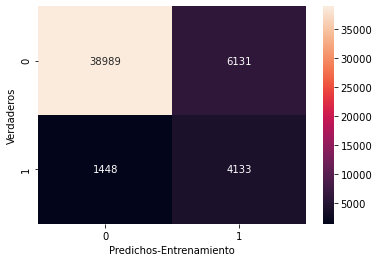

In [67]:
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True,fmt='d')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos-Entrenamiento');

In [68]:
matriz_conf_train = confusion_matrix(y_train, y_pred_train)
score_train = accuracy_score(y_train, y_pred_train)
reporte_train = classification_report(y_train, y_pred_train)
print(matriz_conf_train)
print(score_train)
print(reporte_train)

[[38989  6131]
 [ 1448  4133]]
0.8505157689197451
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     45120
           1       0.40      0.74      0.52      5581

    accuracy                           0.85     50701
   macro avg       0.68      0.80      0.72     50701
weighted avg       0.90      0.85      0.87     50701



In [69]:
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 =f1_score(y_train,y_pred_train)
train_precision =precision_score(y_train, y_pred_train)
train_recall =recall_score(y_train, y_pred_train)


In [87]:
# extraemos el nombre del modelo que se utilizo
modelo = (str(search.best_estimator_.named_steps['clf']).split('=')[1]).split('(')[0]
modelo = 'CatBoost_Full'

In [88]:
# guardamos los resultados del predict.train y los del predict.test
columns = ['sufijo','tipo','modelo','accuracy','f1_score','precision_score','recall_score']
data = {'sufijo':  [sufijo],
        'tipo': ['train'],
        'modelo':[modelo],
        'accuracy':[train_accuracy],
        'f1_score':[train_f1],
        'precision_score':[train_precision],
        'recall_score':[train_recall]
        }

res = pd.DataFrame (data, columns = columns)


res.to_csv('../Datos/metrics.csv', mode='a', header=(not os.path.isfile('../Datos/metrics.csv')),index=False)

###  Prediccion

In [72]:
y_pred =search.best_estimator_.predict(X_test)

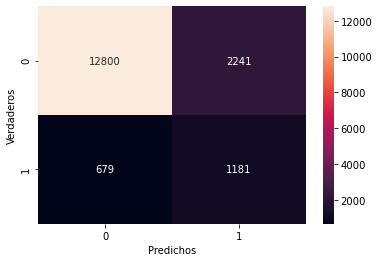

In [73]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos');

In [74]:
matriz_conf = confusion_matrix(y_test, y_pred)
score = accuracy_score(y_test, y_pred)
reporte = classification_report(y_test, y_pred)
print(matriz_conf)
print(score)
print(reporte)

[[12800  2241]
 [  679  1181]]
0.8272291580379859
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     15041
           1       0.35      0.63      0.45      1860

    accuracy                           0.83     16901
   macro avg       0.65      0.74      0.67     16901
weighted avg       0.88      0.83      0.85     16901



<a id="fit"></a>
#### Métricas del modelo Test


In [75]:
x = pd.DataFrame.from_dict(search.cv_results_)
x.to_csv('../Datos/resultados'+sufijo+'.csv')

In [76]:
pred_accuracy = accuracy_score(y_test, y_pred)
pred_f1 =f1_score(y_test,y_pred)
pred_precision =precision_score(y_test, y_pred)
pred_recall =recall_score(y_test, y_pred)

In [79]:
# extraemos el nombre del modelo que se utilizo
modelo = (str(search.best_estimator_.named_steps['clf']).split('=')[1]).split('C')[0]

In [85]:
modelo='CatBoost_Full'
sufijo

'_CatBoost'

In [86]:
# guardamos los resultados del predict.train y los del predict.test
columns = ['sufijo','tipo','modelo','accuracy','f1_score','precision_score','recall_score']
data = {'sufijo':  [sufijo],
        'tipo': ['test'],
        'modelo':[modelo],
        'accuracy':[pred_accuracy],
        'f1_score':[pred_f1],
        'precision_score':[pred_precision],
        'recall_score':[pred_recall]
        }

res = pd.DataFrame (data, columns = columns)

res.to_csv('../Datos/metrics.csv', mode='a', header=False,index=False)